In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import shap

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Data loaded successfully")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data loaded successfully
X_train shape: (20232, 9)
X_test shape: (5059, 9)


In [3]:
# Baseline
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

# Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

results = pd.DataFrame({
    'Model': [
        'Baseline (mean)',
        'Linear Regression',
        'Ridge Regression',
        'Random Forest'
    ],
    'MSE': [baseline_mse, lr_mse, ridge_mse, rf_mse],
    'RMSE': [baseline_rmse, lr_rmse, ridge_rmse, rf_rmse],
    'MAE': [baseline_mae, lr_mae, ridge_mae, rf_mae],
    'R2': [baseline_r2, lr_r2, ridge_r2, rf_r2]
})

print("=== MODEL RESULTS ===")
print(results.round(4))

=== MODEL RESULTS ===
               Model     MSE    RMSE     MAE      R2
0    Baseline (mean)  0.0198  0.1407  0.1159 -0.0000
1  Linear Regression  0.0182  0.1349  0.1107  0.0809
2   Ridge Regression  0.0182  0.1349  0.1107  0.0809
3      Random Forest  0.0184  0.1356  0.1114  0.0717


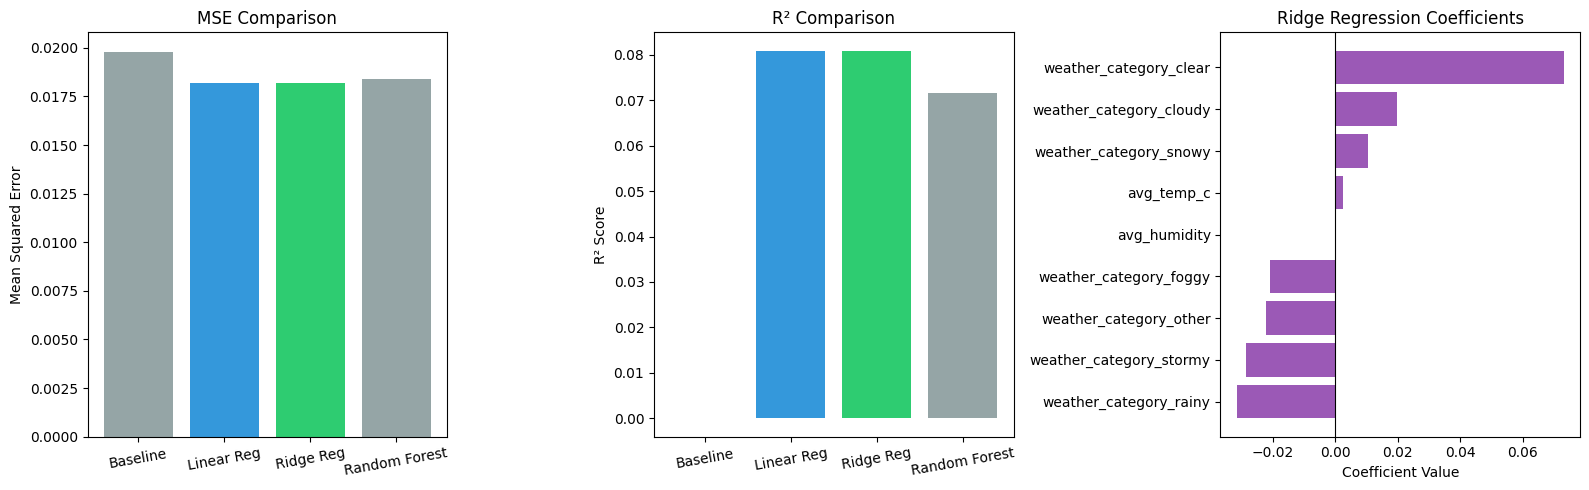


Ridge Coefficients:
                feature  coefficient
 weather_category_rainy      -0.0316
weather_category_stormy      -0.0286
 weather_category_other      -0.0222
 weather_category_foggy      -0.0210
           avg_humidity      -0.0003
             avg_temp_c       0.0023
 weather_category_snowy       0.0105
weather_category_cloudy       0.0199
 weather_category_clear       0.0731


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Model comparison bar chart
models = ['Baseline', 'Linear Reg', 'Ridge Reg', 'Random Forest']
mse_vals = [baseline_mse, lr_mse, ridge_mse, rf_mse]
r2_vals = [baseline_r2, lr_r2, ridge_r2, rf_r2]

axes[0].bar(models, mse_vals, color=['#95a5a6', '#3498db', '#2ecc71'])
axes[0].set_title('MSE Comparison')
axes[0].set_ylabel('Mean Squared Error')
axes[0].tick_params(axis='x', rotation=10)

# Plot 2: R2 comparison
axes[1].bar(models, r2_vals, color=['#95a5a6', '#3498db', '#2ecc71'])
axes[1].set_title('R² Comparison')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=10)

# Plot 3: Feature coefficients from Ridge
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ridge.coef_
}).sort_values('coefficient')

axes[2].barh(coef_df['feature'], coef_df['coefficient'], color='#9b59b6')
axes[2].set_title('Ridge Regression Coefficients')
axes[2].set_xlabel('Coefficient Value')
axes[2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../results/figures/regression_results.png', dpi=150)
plt.show()

print("\nRidge Coefficients:")
print(coef_df.round(4).to_string(index=False))

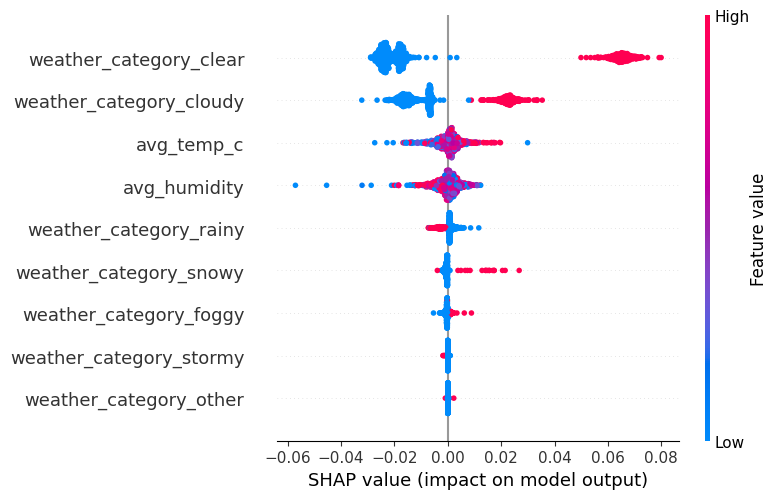

In [5]:
# SHAP values for Random Forest
explainer = shap.TreeExplainer(rf)

# Use a sample so it runs faster
X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.savefig('../results/figures/random_forest_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()